In [1]:
# %pip install git+https://github.com/Mishne-Lab/pyRATS
# if not already installed on the system:
# %pip install pandas imageio seaborn matplotlib

import sys
sys.path.insert(0, '../src/')
sys.path.insert(0, '../')

from pyRATS import rats
from examples import vis

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

Note that the data loaded here is from:
Saxena, S., Russo, A. A., Cunningham, J., & Churchland, M. M. (2022). Motor cortex activity across movement speeds is predicted by network-level strategies for generating muscle activity. eLife, 11, e67620. https://doi.org/10.7554/eLife.67620

In [2]:
import os
import pickle

def path_exists(path):
    return os.path.exists(path) or os.path.islink(path)

def read(fpath, verbose=True):
    if not path_exists(fpath):
        if verbose:
            print(fpath, 'does not exist.')
        return None
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    if verbose:
        print('Read data from', fpath, flush=True)
    return data


In [3]:
data_fname = '../data/motor_data.dat'             # PATH TO DATA
X, labels, metadata = read(data_fname)
cond_num = metadata['cond_num']

Read data from ../../../RATS/code/motor_cortex/notebooks/data/data.dat


# Generate embeddings

In [4]:
model = rats.RATS(
    n_components = 2,
    n_neighbors = 45,
    cost_function = 'alignment',
    min_cluster_size=3,
    patience=20,
    n_iter=20,
    tear=True,
    postprocess=True,
    root_view='center',
    tree='spt',
    verbose=False
)

y, c_labels = model.fit_transform(X, cond_num) # here cond_num is only used to induce connections across trajectories (see methods)

/tmp/ipykernel_27105/3229266268.py:1: DeprecationWarning: The parameter 'patience' is deprecated and will be removed in a future release. Use 'n_iter_without_progress' instead.
  model = rats.RATS(


<Axes: >

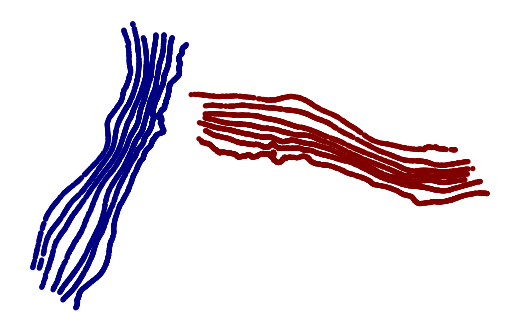

In [5]:
# colored by detected cluster label
vis.Visualize().global_embedding(
    y, c_labels,
    cmap0='jet',
    title='color='+str([1]),
    figsize=(5,5)
)

<Axes: >

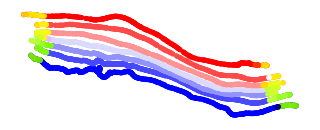

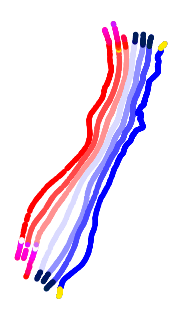

In [6]:
# colored by condition number with gluing instructions
def f(x):
    z = x.copy()
    mask = x < 6
    z[mask] -= 2
    z[~mask] -= 1
    return z

tear_color_eig_inds = [1]
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds=tear_color_eig_inds, 
)

mask_pos = cond_num>0
vis.Visualize().global_embedding(
    y[mask_pos], f(cond_num[mask_pos]),
    color_of_pts_on_tear=color_of_pts_on_tear[mask_pos][:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='bwr',
    cmap1='gist_ncar',
    title='color='+str([1]),
    figsize=(3,3)
)

mask_neg = cond_num<0
vis.Visualize().global_embedding(
    y[mask_neg], f(-cond_num[mask_neg]),
    color_of_pts_on_tear=color_of_pts_on_tear[mask_neg][:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='bwr',
    cmap1='gist_ncar',
    title='color='+str([1]),
    figsize=(3,3)
)
